In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import plotly.graph_objects as go
import geopandas as gpd
import matplotlib.pyplot as plt
# Fix: Import cdist from scipy.spatial.distance instead of scipy.spatial
from scipy.spatial.distance import cdist
import mapclassify
import matplotlib.patches as mpatches 

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines

In [ ]:
file_path = "TT_station_timeseries.csv"
df = pd.read_csv(file_path)  # or your DataFrame

In [ ]:
print(df)

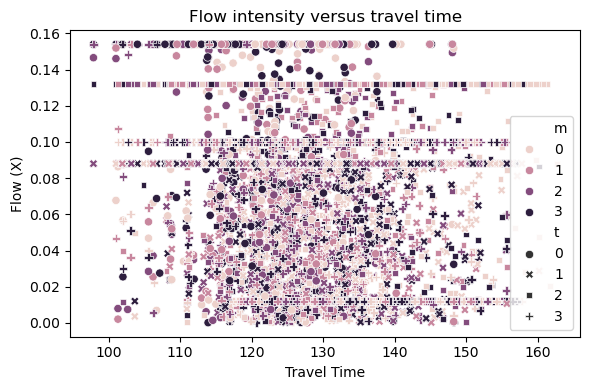

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="travel_time", y="flow_X", hue="m", style="t")
plt.xlabel("Travel Time")
plt.ylabel("Flow (X)")
plt.title("Flow intensity versus travel time")
plt.tight_layout()
plt.show()

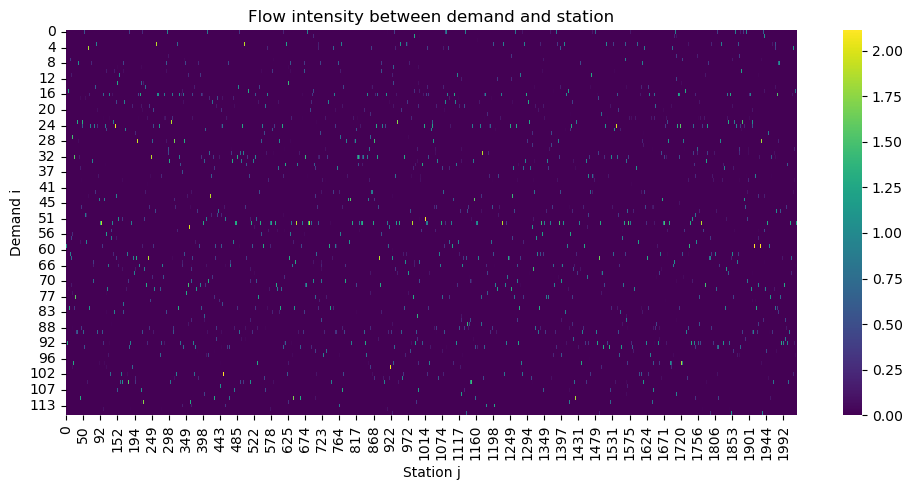

In [14]:
pivot = df.pivot_table(values="flow_X", index="demand_i", columns="station_j", aggfunc="sum", fill_value=0)
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap="viridis")
plt.title("Flow intensity between demand and station")
plt.xlabel("Station j")
plt.ylabel("Demand i")
plt.tight_layout()
plt.show()

In [15]:
print(len(df["station_j"].unique()))

1071


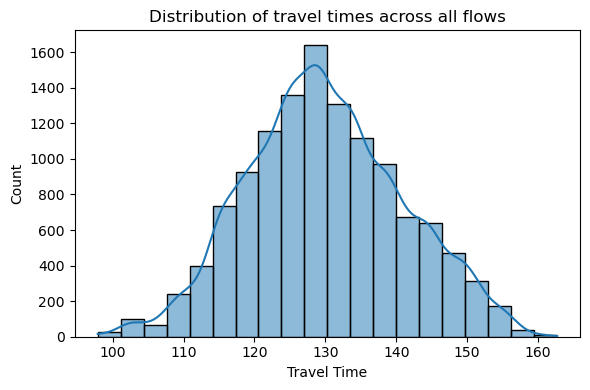

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["travel_time"], bins=20, kde=True)
plt.xlabel("Travel Time")
plt.title("Distribution of travel times across all flows")
plt.tight_layout()
plt.show()


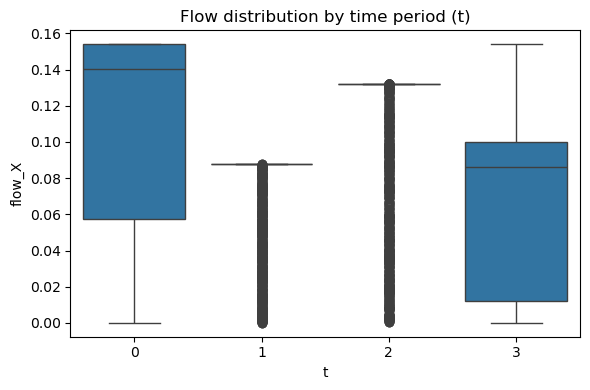

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="t", y="flow_X")
plt.title("Flow distribution by time period (t)")
plt.tight_layout()
plt.show()


In [18]:
# Filter only positive flows
df_active = df[df["flow_X"] > 0]

# Count how many unique stations serve each demand point
chargers_per_demand = df_active.groupby("demand_i")["station_j"].nunique().reset_index()
chargers_per_demand.columns = ["demand_i", "n_chargers"]

# Sort or inspect
chargers_per_demand.sort_values("n_chargers", ascending=False).head()



,demand_i,n_chargers
49,52,89
16,16,78
80,92,60
77,89,55
24,24,54


In [19]:
df6 = chargers_per_demand[["demand_i", "n_chargers"]]
print(df6)

    demand_i  n_chargers
0          0          45
1          1           9
2          2           2
3          3          37
4          4          19
..       ...         ...
94       110          15
95       112          17
96       113          11
97       114          11
98       115           9

[99 rows x 2 columns]


In [3]:
file_path2 = "MC_station_timeseries.csv"
df2 = pd.read_csv(file_path2)  # or your DataFrame

# Filter only positive flows
df_active2 = df2[df2["flow_X"] > 0]

# Count how many unique stations serve each demand point
chargers_per_demand2 = df_active2.groupby("demand_i")["station_j"].nunique().reset_index()
chargers_per_demand2.columns = ["demand_i2", "n2_chargers"]

# Sort or inspect
chargers_per_demand2.sort_values("n2_chargers", ascending=False).head()


,demand_i2,n2_chargers
49,52,88
16,16,77
80,92,61
77,89,57
22,22,55


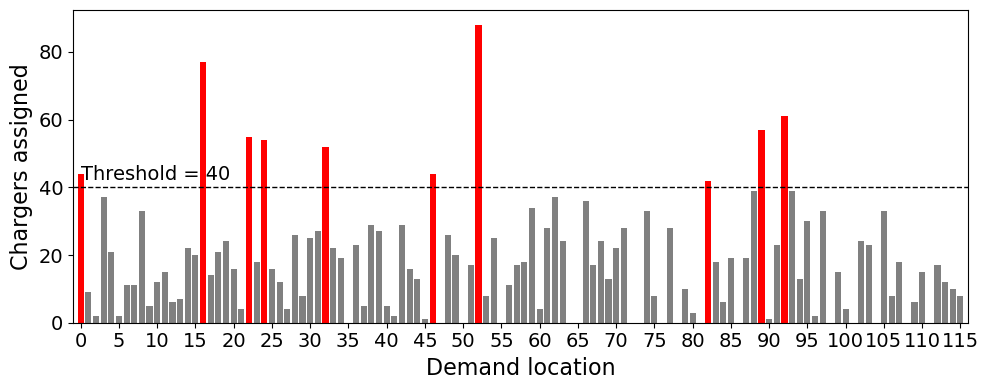

In [144]:
top = chargers_per_demand2.sort_values("n2_chargers", ascending=False)
plt.figure(figsize=(10,4))
colors = ["red" if n > 40 else "gray" for n in top["n2_chargers"]]
plt.bar(top["demand_i2"], top["n2_chargers"], color=colors)
plt.axhline(y=40, color="black", linestyle="--", linewidth=1)
plt.text(0, 41, "Threshold = 40", va="bottom", ha="left", fontsize=14)
plt.xlabel("Demand location", fontsize=16)
plt.ylabel("Chargers assigned", fontsize=16)
#plt.title("FC chargers assigned per demand location")
plt.xticks(range(0, 116, 5), fontsize=14)
plt.xlim(-1, 116)
plt.yticks(fontsize=14)
plt.tight_layout()
#plt.show()

plt.savefig("MC_run_chargers_per_demand.png", dpi=1200, bbox_inches='tight')
#plt.close()

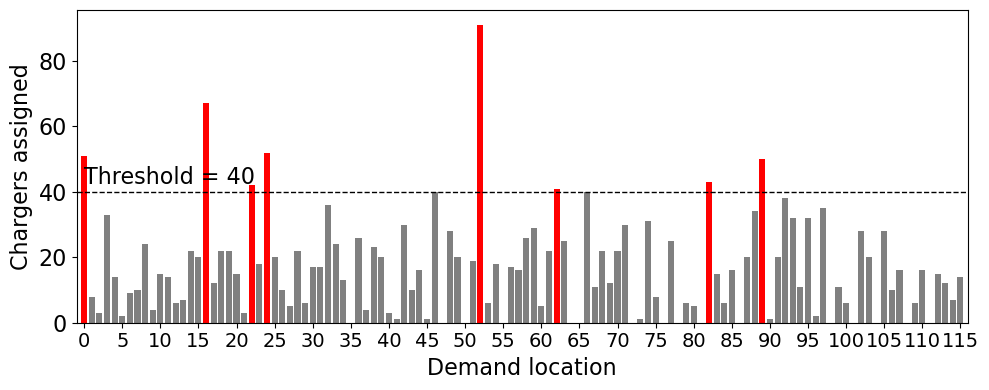

In [147]:

file_path3 = "TT_station_timeseries.csv"
df3 = pd.read_csv(file_path3)

# Filter only positive flows
df_active3 = df3[df3["flow_X"] > 0]

# Count how many unique stations serve each demand point
chargers_per_demand3 = df_active3.groupby("demand_i")["station_j"].nunique().reset_index()
chargers_per_demand3.columns = ["demand_i2", "n2_chargers"]

# Sort or inspect
chargers_per_demand3.sort_values("n2_chargers", ascending=False).head()
top = chargers_per_demand3.sort_values("n2_chargers", ascending=False)
plt.figure(figsize=(10,4))
colors = ["red" if n > 40 else "gray" for n in top["n2_chargers"]]
plt.bar(top["demand_i2"], top["n2_chargers"], color=colors)
plt.axhline(y=40, color="black", linestyle="--", linewidth=1)
plt.text(0, 41, "Threshold = 40", va="bottom", ha="left", fontsize=16)
plt.xlabel("Demand location", fontsize=16)
plt.ylabel("Chargers assigned", fontsize=16)
#plt.title("FC chargers assigned per demand location")
plt.xticks(range(0, 116, 5), fontsize=14)
plt.xlim(-1, 116)
plt.yticks(fontsize=16)
plt.tight_layout()
#plt.show()

plt.savefig("TT_run_chargers_per_demand.png", dpi=1200, bbox_inches='tight')
#plt.close()

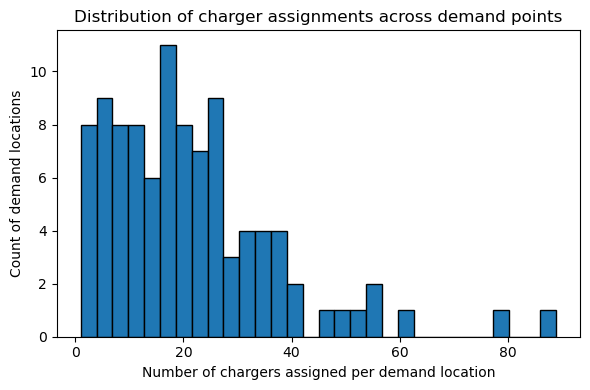

In [208]:
plt.figure(figsize=(6,4))
plt.hist(df["n_chargers"], bins=30, edgecolor='black')
plt.xlabel("Number of chargers assigned per demand location")
plt.ylabel("Count of demand locations")
plt.title("Distribution of charger assignments across demand points")
plt.tight_layout()
plt.show()


In [81]:
df_active = df[df["flow_X"] > 0]

# Aggregate chargers and energy per demand point
summary = (
    df_active.groupby("demand_i")
    .agg(
        n_chargers=("station_j", "nunique"),
        total_energy=("flow_X", "sum")
    )
    .reset_index()
)

# Sort and inspect
summary.sort_values("total_energy", ascending=False).head()


,demand_i,n_chargers,total_energy
48,52,89,100.055893
16,16,67,51.745034
24,24,52,48.823052
32,32,37,37.534198
79,92,38,32.418353


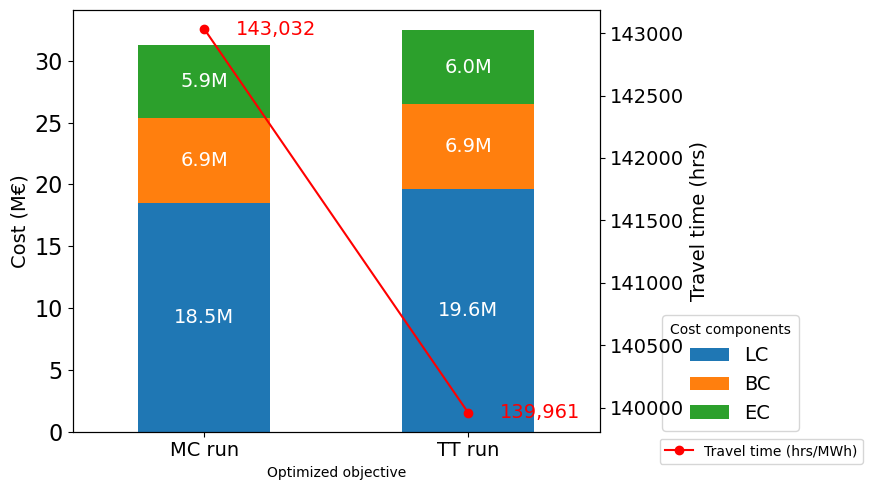

In [168]:

# Data
# data = {
#     "Optimized objective": ["TT run", "MC run"],
#     "LC": [19601815.223606735, 18493081.909626648],
#     "BC": [6866319.2716340665, 6866319.2716340665],
#     "EC": [6018402.884847512, 5890497.079195945  ],
#     "TT": [139960.52, 143032.16],
# }
#Newww
data = {
    "Optimized objective": ["MC run", "TT run"],
    "LC": [18493081.909626648, 19601815.223606735],
    "BC": [6866319.2716340665, 6866319.2716340665],
    "EC": [5890497.079195945, 6018402.884847512],
    "TT": [143032.16, 139960.52],
}

df = pd.DataFrame(data).set_index("Optimized objective")

# Convert costs to millions of euros
df_plot = df.copy()
df_plot[["LC", "BC", "EC"]] = df_plot[["LC", "BC", "EC"]] / 1e6  # → M€

# Stacked cost bars
ax = df_plot[["LC", "BC", "EC"]].plot(
    kind="bar", stacked=True, figsize=(9,5),
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],  fontsize=16
)
ax.set_ylabel("Cost (M€)", fontsize=14)
#ax.set_title("Cost and travel time comparison: TT and Fixed costs")
ax.set_xticklabels(df_plot.index, rotation=0,  fontsize=14)


# Add labels inside bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f"{height:.1f}M",
                ha="center", va="center", fontsize=14, color="white"
            )

# Travel time line + secondary axis
ax2 = ax.twinx()
ax2.plot(df_plot.index, df_plot["TT"], color="red", marker="o", label="Travel time (hrs/MWh)")
ax2.set_ylabel("Travel time (hrs)", fontsize=14)
ax2.tick_params(axis='y', labelsize=14)
# Travel time labels
for i, val in enumerate(df_plot["TT"]):
    ax2.text(
        i + 0.12, val,
        f"{val:,.0f}",
        color="red", ha="left", va="center", fontsize=14 #fontweight="bold"
    )

# Legends and layout
ax.legend(title="Cost components", bbox_to_anchor=(1.10,0.3), loc="upper left", fontsize=14)
ax2.legend(bbox_to_anchor=(1.10, 0.00001), loc="upper left")
plt.tight_layout()
#plt.savefig("Cost_objective_comparison.png", dpi=1200, bbox_inches='tight')
#plt.show()


In [9]:
data = {
    "Optimized objective": ["TT run", "MC run"],
    "LC": [19601815.223606735, 18493081.909626648],
    "BC": [6866319.2716340665, 6866319.2716340665],
    "EC": [6018402.884847512, 5890497.079195945],
    "TT": [139960.52, 143032.16],
}

df = pd.DataFrame(data)

df["Monetary Cost (€)"] = df["LC"] + df["BC"] + df["EC"]

payoff_matrix = df[
    ["Optimized objective", "Monetary Cost (€)", "TT"]
].copy()

payoff_matrix


,Optimized objective,Monetary Cost (€),TT
0,TT run,3.248654e+07,139960.52
1,MC run,3.124990e+07,143032.16


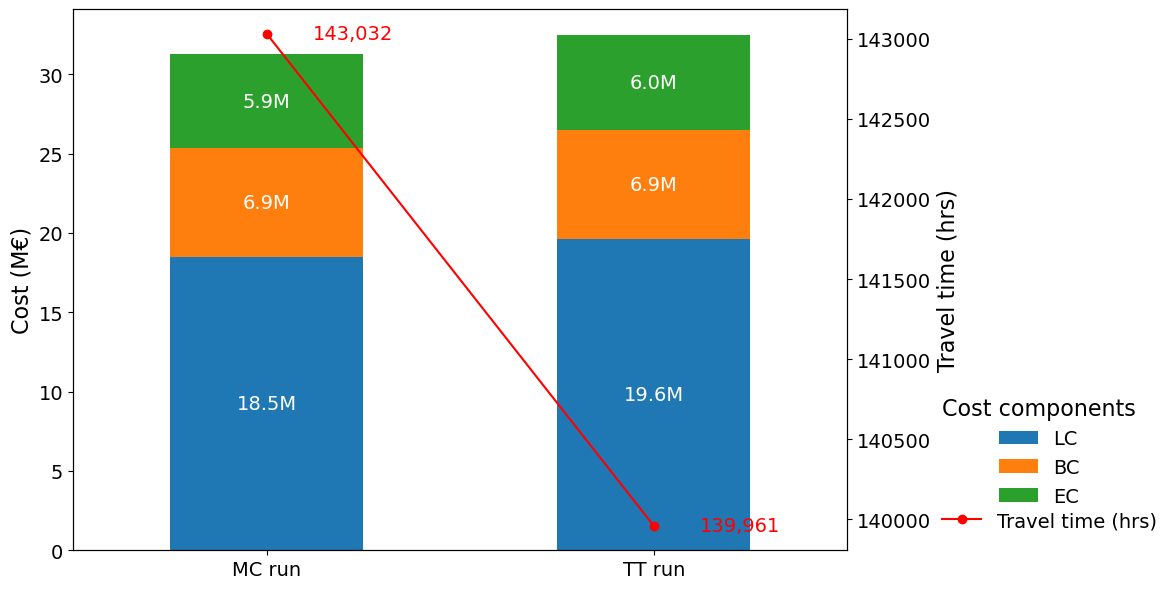

In [192]:
#Newww
data = {
    "Optimized objective": ["MC run", "TT run"],
    "LC": [18493081.909626648, 19601815.223606735],
    "BC": [6866319.2716340665, 6866319.2716340665],
    "EC": [5890497.079195945, 6018402.884847512],
    "TT": [143032.16, 139960.52],
}

df = pd.DataFrame(data).set_index("Optimized objective")

# Convert costs to millions of euros
df_plot = df.copy()
df_plot[["LC", "BC", "EC"]] = df_plot[["LC", "BC", "EC"]] / 1e6  # M€

# -----------------------------
# Font control
# -----------------------------
FS_LABEL  = 16
FS_TICK   = 14
FS_LEGEND = 14
FS_BAR    = 14
FS_ANNOT  = 14

# -----------------------------
# Plot: stacked costs
# -----------------------------
ax = df_plot[["LC", "BC", "EC"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
    fontsize=FS_TICK
)

ax.set_ylabel("Cost (M€)", fontsize=FS_LABEL)
ax.set_xlabel("")
ax.set_xticklabels(df_plot.index, rotation=0, fontsize=FS_TICK)
ax.tick_params(axis="y", labelsize=FS_TICK)

# Labels inside bars
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                f"{h:.1f}M",
                ha="center",
                va="center",
                fontsize=FS_BAR,
                color="white"
            )

# -----------------------------
# Travel time line + secondary axis
# -----------------------------
ax2 = ax.twinx()
ax2.plot(
    df_plot.index,
    df_plot["TT"],
    color="red",
    marker="o",
    label="Travel time (hrs)"
)

ax2.set_ylabel("Travel time (hrs)", fontsize=FS_LABEL)
ax2.tick_params(axis="y", labelsize=FS_TICK)

# Travel time labels
for i, val in enumerate(df_plot["TT"]):
    ax2.text(
        i + 0.12,
        val,
        f"{val:,.0f}",
        color="red",
        ha="left",
        va="center",
        fontsize=FS_ANNOT
    )

# -----------------------------
# Legends with explicit position control
# Coordinates are in axes fraction: (0,0)=bottom-left, (1,1)=top-right
# -----------------------------
leg1 = ax.legend(
    title="Cost components",
    fontsize=FS_LEGEND,
    title_fontsize=FS_LABEL,
    frameon=False
)
leg1.set_loc("lower left")
leg1.set_bbox_to_anchor((1.1, 0.05))   # move this (x, y)

leg2 = ax2.legend(
    fontsize=FS_LEGEND,
    frameon=False
)
leg2.set_loc("lower left")
leg2.set_bbox_to_anchor((1.1, 0.005))   # move this (x, y)

plt.tight_layout()
plt.savefig("Cost_objective_comparison.png", dpi=1200, bbox_inches='tight')
#plt.show()


JACARD INDEX

In [14]:
TT_opened_list =pd.read_csv("MC_sites_selected_fixed_cost_.csv")
MC_opened_list =pd.read_csv("TT_run_sites_selected_.csv")
print(TT_opened_list)

         j  ID_unique      POINT_X      POINT_Y    Y   LandPrice  Grid_supply  \
0        0          1  159582.4529  384981.8982  1.0  186.785400          111   
1        1          5  163559.2399  381151.1635  1.0  329.000000          207   
2        4         12  159664.3590  384622.0184  1.0  266.786194          111   
3        5         18  162758.6570  387929.8815  1.0  310.963165          207   
4        9         30  163603.6352  383195.3422  1.0  289.643158          207   
...    ...        ...          ...          ...  ...         ...          ...   
1066  2022       5973  161332.7672  387626.9488  1.0  323.937988          207   
1067  2027       5989  160496.4608  386786.9415  1.0  289.500000          111   
1068  2028       5990  161633.9427  387879.7736  1.0  308.023010          207   
1069  2031       5997  163275.9948  383941.3251  1.0  325.130707          207   
1070  2032       6000  161490.9400  383559.1182  1.0  322.541168          207   

      Actual_required_MW  A

In [22]:
# Suppose these are lists of station IDs opened in each run

opened_TT = set(TT_opened_list["ID_unique"])        # e.g. [12, 54, 88, ...]
opened_MC = set(MC_opened_list["ID_unique"])       # e.g. [12, 54, 90, ...]

# Convert to sets
S_TT = set(opened_TT)
S_MC = set(opened_MC)

# Compute Jaccard index
intersection = S_TT & S_MC
union = S_TT | S_MC

jaccard = len(intersection) / len(union)

print("Opened TT:", len(S_TT))
print("Opened MC:", len(S_MC))
print("Intersection:", len(intersection))
print("Union:", len(union))
print("Jaccard index:", jaccard)

Opened TT: 1071
Opened MC: 1071
Intersection: 885
Union: 1257
Jaccard index: 0.7040572792362768


In [23]:
only_TT = opened_TT - opened_MC
only_MC = opened_MC - opened_TT
print(len(only_TT), len(only_MC))


186 186


In [24]:
TT_only_coords = TT_opened_list[TT_opened_list["ID_unique"].isin(only_TT)][["POINT_X","POINT_Y"]]
MC_only_coords = MC_opened_list[MC_opened_list["ID_unique"].isin(only_MC)][["POINT_X","POINT_Y"]]



In [25]:
import scipy.stats as st
st.ttest_ind(
    TT_opened_list[TT_opened_list.ID_unique.isin(only_TT)]["LandPrice"],
    MC_opened_list[MC_opened_list.ID_unique.isin(only_MC)]["LandPrice"]
)


TtestResult(statistic=np.float64(-18.692826214230454), pvalue=np.float64(2.230973794881363e-55), df=np.float64(370.0))

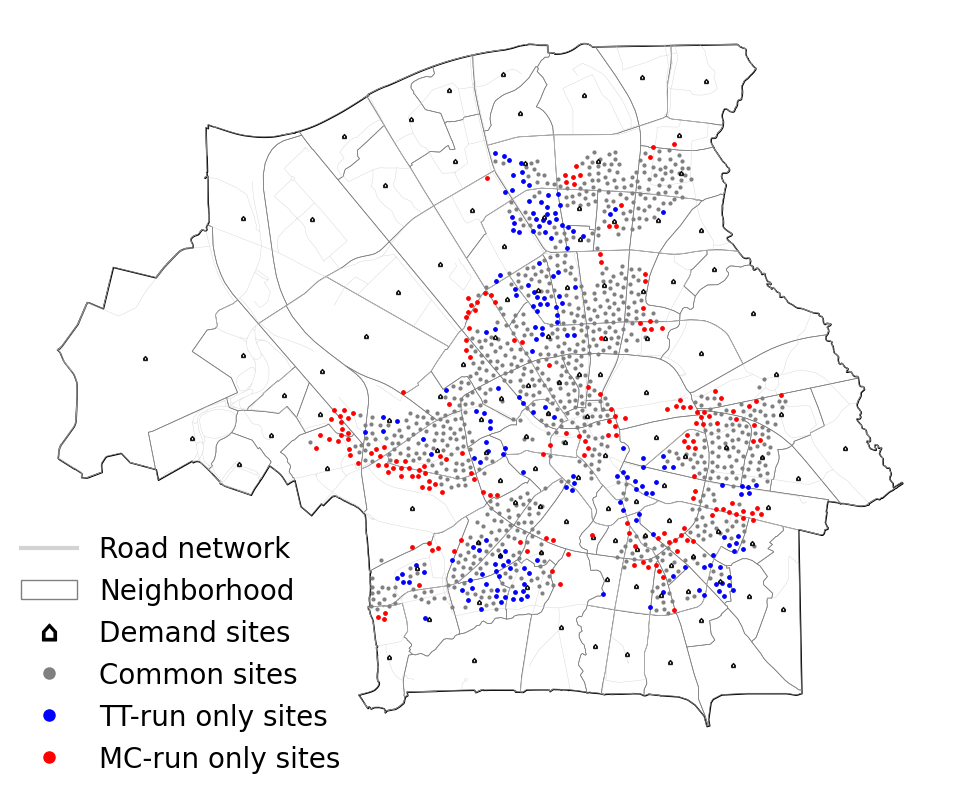

In [124]:

# --- Load base layers and unify CRS ---
boundary = gpd.read_file("Eindhovenmap.shp").to_crs("EPSG:28992")
road_net = gpd.read_file("Road_layer.shp").to_crs("EPSG:28992")
neighborhood = gpd.read_file("TT_eindhoven_neighbo.shp").to_crs("EPSG:28992")
demand =gpd.read_file("EV_Demand_2024_eindhoven.csv")

# Clip roads to boundary
road_net = gpd.clip(road_net, boundary)

# --- Create GeoDataFrames for TT and MC opened sites ---
gdf_TT = gpd.GeoDataFrame(
    TT_opened_list,
    geometry=gpd.points_from_xy(TT_opened_list["POINT_X"], TT_opened_list["POINT_Y"]),
    crs="EPSG:28992"
)
gdf_MC = gpd.GeoDataFrame(
    MC_opened_list,
    geometry=gpd.points_from_xy(MC_opened_list["POINT_X"], MC_opened_list["POINT_Y"]),
    crs="EPSG:28992"
)

demand_sites = gpd.GeoDataFrame(
    demand,
    geometry=gpd.points_from_xy(demand["POINT_X"], demand["POINT_Y"]),
    crs="EPSG:28992"
)


# --- Subsets ---
gdf_TT_only = gdf_TT[gdf_TT["ID_unique"].isin(only_TT)]
gdf_MC_only = gdf_MC[gdf_MC["ID_unique"].isin(only_MC)]
gdf_common  = gdf_TT[gdf_TT["ID_unique"].isin(opened_TT & opened_MC)]

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Base layers
boundary.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1, zorder=1)
neighborhood.boundary.plot(ax=ax, color="grey", linewidth=0.5, zorder=2)
road_net.plot(ax=ax, color="lightgrey", linewidth=0.3, zorder=3)

# EVCS layers
gdf_common.plot(ax=ax, color="grey", markersize=4, zorder=4)
gdf_TT_only.plot(ax=ax, color="blue", markersize=6, zorder=5)
gdf_MC_only.plot(ax=ax, color="red",  markersize=6, zorder=6)
# Demand: hollow house, readable but not dominant
demand_sites.plot(
    ax=ax,
    marker="$\u2302$",
    markersize=10,
    facecolor="white",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.90,
    zorder=5
)


# Remove outer border
for spine in ax.spines.values():
    spine.set_visible(False)

# # North arrow (axes coords)
# x, y, arrow_length = 0.1, 1, 0.1
# ax.annotate(
#     'N', xy=(x, y), xytext=(x, y - arrow_length),
#     arrowprops=dict(facecolor='black', width=5, headwidth=15),
#     ha='center', va='center', fontsize=16, xycoords=ax.transAxes
# )

# # Scale bar (map coords; EPSG:28992 is meters)
# minx, miny, maxx, maxy = boundary.total_bounds
# scalebar_length = 2000  # 2 km
# bar_x0 = minx + 5500
# bar_y  = miny - 400
# ax.plot([bar_x0, bar_x0 + scalebar_length], [bar_y, bar_y], color='black', linewidth=3)
# ax.text(bar_x0 + scalebar_length/2, bar_y + 100, "2 km", ha='center', va='bottom', fontsize=12)

# Clean axes
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

# --- Legend with proxies (adds roads/neighborhoods) ---
common_proxy = mlines.Line2D([], [], color='grey', marker='o', linestyle='None', markersize=8, label='Common sites')
tt_proxy     = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=8, label='TT-run only sites')
mc_proxy     = mlines.Line2D([], [], color='red',  marker='o', linestyle='None', markersize=8, label='MC-run only sites')
roads_proxy  = mlines.Line2D([], [], color='lightgrey', linewidth=3, label='Road network')
neigh_proxy  = mpatches.Patch(edgecolor='grey', facecolor='none', label='Neighborhood')
demand_sites = mlines.Line2D([], [], color='Black', marker="$\u2302$", linestyle='None', markersize=12, label='Demand sites')

ax.legend(handles=[roads_proxy, neigh_proxy, demand_sites, common_proxy, tt_proxy, mc_proxy, ],
          loc='lower left', bbox_to_anchor=(-0.02, -0.05), frameon=False, fontsize=20)

plt.savefig("EVCS_distr_comparison_between_TT_MC.png", dpi=1200, bbox_inches='tight')


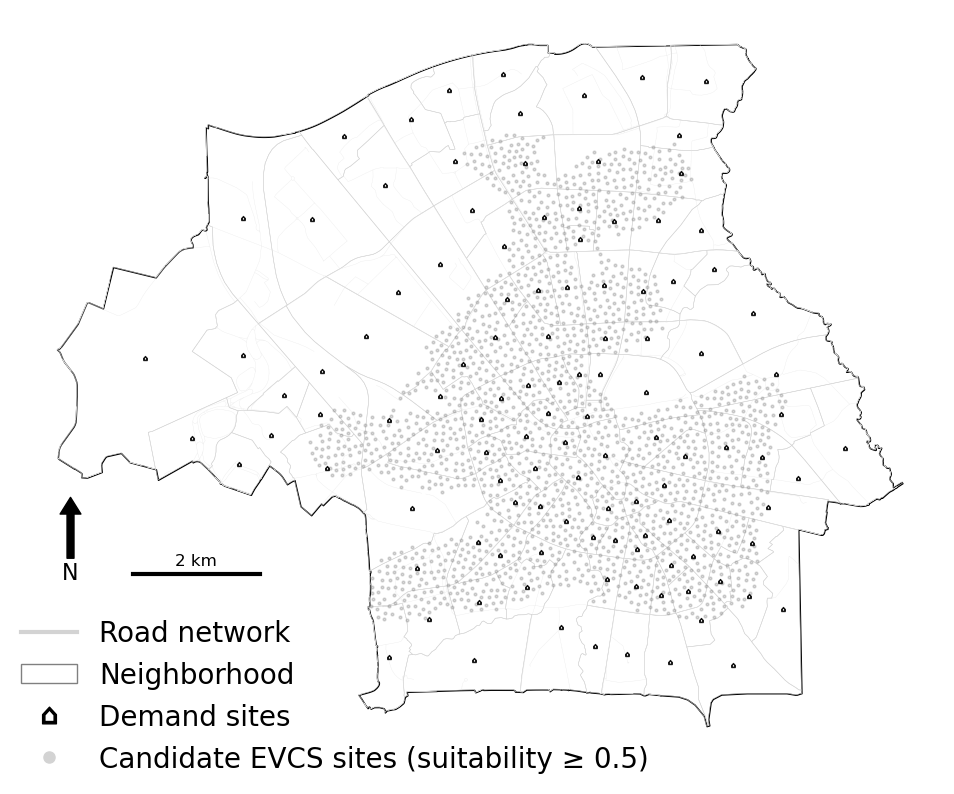

In [125]:
orginal_EVCS = gpd.read_file("Chargers_with_Probability_Greater_than_0.5.csv")
demand =gpd.read_file("EV_Demand_2024_eindhoven.csv")

# --- Create GeoDataFrames for TT and MC opened sites ---
OG_sites = gpd.GeoDataFrame(
    orginal_EVCS,
    geometry=gpd.points_from_xy(orginal_EVCS["POINT_X"], orginal_EVCS["POINT_Y"]),
    crs="EPSG:28992"
)

demand_sites = gpd.GeoDataFrame(
    demand,
    geometry=gpd.points_from_xy(demand["POINT_X"], demand["POINT_Y"]),
    crs="EPSG:28992"
)
# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12), frameon = False)

# # Base layers
# boundary.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1, zorder=1)
# neighborhood.boundary.plot(ax=ax, color="grey", linewidth=0.5, zorder=2)
# road_net.plot(ax=ax, color="lightgrey", linewidth=0.3, zorder=3)
# OG_sites.plot(ax=ax, color="lightgrey", markersize=2, zorder=5)
# demand_sites.plot(ax=ax, marker="$\u2302$", markersize=11, facecolor="white", edgecolor="black", linewidth=0.8,  alpha=0.9, zorder=5)


# Base layers (Map 1: visually quieter baseline)

boundary.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1.0, zorder=1)

# Lighter, thinner neighborhood boundaries
neighborhood.boundary.plot(ax=ax, color="lightgrey", linewidth=0.35, zorder=2)

# De-emphasize roads: lighter + thinner
road_net.plot(ax=ax, color="#e6e6e6", linewidth=0.20, zorder=3)

# Candidate sites should be background texture: smaller + transparent
OG_sites.plot(ax=ax, color="grey", markersize=4, alpha=0.30, zorder=4)

# Demand: hollow house, readable but not dominant
demand_sites.plot(
    ax=ax,
    marker="$\u2302$",
    markersize=10,
    facecolor="white",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.90,
    zorder=5
)

# Remove outer border
for spine in ax.spines.values():
    spine.set_visible(False)
# North arrow (axes coords)
x, y, arrow_length = 0.06, 0.35, 0.1
ax.annotate(
    'N', xy=(x, y), xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor='black', width=5, headwidth=15),
    ha='center', va='center', fontsize=16, xycoords=ax.transAxes
)
# Scale bar (map coords; EPSG:28992 is meters)
minx, miny, maxx, maxy = boundary.total_bounds
scalebar_length = 2000  # 2 km
bar_x0 = minx + 1200
bar_y  = miny + 2400
ax.plot([bar_x0, bar_x0 + scalebar_length], [bar_y, bar_y], color='black', linewidth=3)
ax.text(bar_x0 + scalebar_length/2, bar_y + 100, "2 km", ha='center', va='bottom', fontsize=12)
# Clean axes
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

# --- Legend with proxies (adds roads/neighborhoods) ---
neigh_proxy  = mpatches.Patch(edgecolor='grey', facecolor='none', label='Neighborhood')
roads_proxy  = mlines.Line2D([], [], color='lightgrey', linewidth=3, label='Road network')
demand_proxy = mlines.Line2D([], [], color='Black', marker="$\u2302$", linestyle='None', markersize=12, label='Demand sites')
OG_sites     = mlines.Line2D([], [], color='lightgrey', marker='o', linestyle='None', markersize=8, label='Candidate EVCS sites (suitability ≥ 0.5)')
ax.legend(
    handles=[roads_proxy, neigh_proxy, demand_proxy, OG_sites],
    loc="lower left",
    bbox_to_anchor=(-0.02, -0.05),
    frameon=False,
    fontsize=20
)
 
plt.savefig("Orginal_EVCS_location.jpg", dpi=1200, bbox_inches='tight')